# 1 · Modelos base (AE / DAE / VAE) y búsqueda de hiperparámetros

Arrancamos con autoencoders clásicos. **Hallazgo central:** el *score* importa
más que la arquitectura. El VAE con `recon_prob` (An & Cho 2015) — que pondera el
error de cada feature por su varianza esperada — supera por lejos al MSE plano del
AE/DAE.

Tuneamos 7 variantes de AE: el rango de PR-AUC fue de solo **0.034** → el cuello de
botella no eran los hiperparámetros sino el enfoque (score y varianza).

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## AE / DAE / VAE: el score es lo que diferencia (soja)

In [2]:
explib.show(explib.tbl_baselines())

,modelo,soja_pr,nota
0,IForest (baseline tuneado),0.511,"no neuronal, ensamble estable"
1,VAE recon_prob (single),0.559,score probabilístico (An & Cho)
2,AE seed-ensemble (MSE),0.339,MSE plano: dramáticamente peor
3,DAE seed-ensemble (MSE),0.413,denoising ayuda algo vs AE
4,AE score=max,0.329,max error por feature: no ayuda


- **AE/DAE con MSE plano**: 0.33–0.41, muy por debajo.
- **VAE `recon_prob`**: 0.559 — el score probabilístico es el diferenciador.
- El `score=max` (máximo error por feature) no ayudó: el problema no era el agregador.

### Distribución de scores del VAE (separación normal vs anómala)

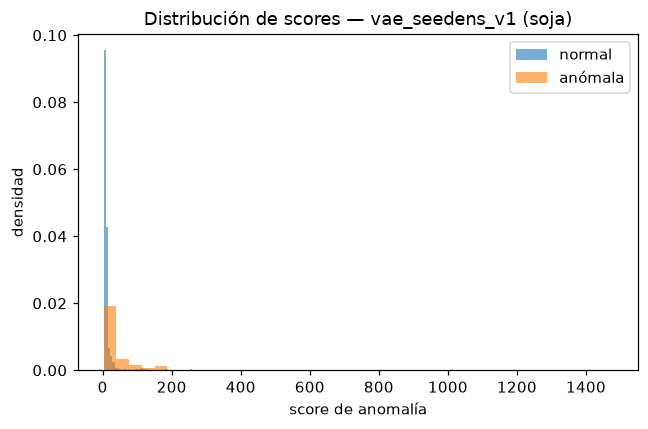

In [3]:
explib.plot_score_hist("vae_seedens_v1", "soja"); plt.show()

### Curva de loss del entrenamiento del VAE (train vs val, por época)

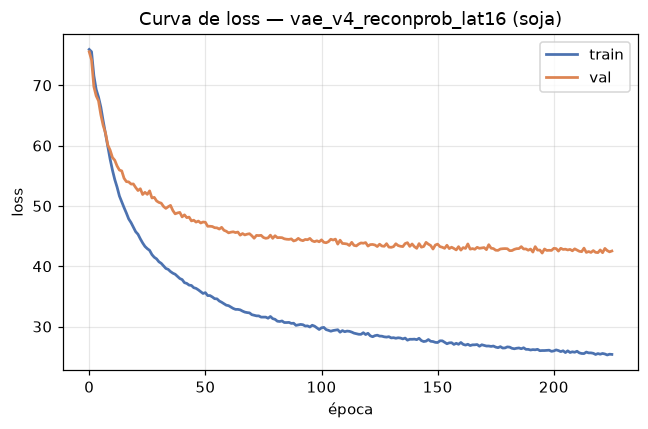

In [4]:
explib.plot_loss("vae_v4_reconprob_lat16", "soja"); plt.show()

El early-stopping corta cuando la val_loss deja de mejorar (restaura la mejor
época). El `recon_prob` se evalúa sobre ese modelo entrenado.

### Todas las métricas del VAE (test, con desvío estándar entre seeds)

In [5]:
explib.show(explib.run_metrics("vae_v4_reconprob_lat16", "soja"))

,metrica,valor,std
0,PR-AUC,0.5591,0.0348
1,ROC-AUC,0.7190,0.0272
2,F1,0.4859,0.0263
3,Precision@k,0.5183,0.0354
4,Recall@contam,0.2786,0.0176


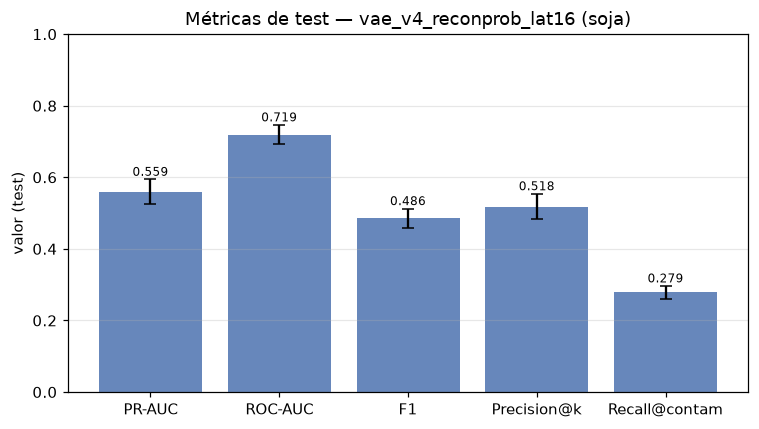

In [6]:
explib.plot_all_metrics("vae_v4_reconprob_lat16", "soja"); plt.show()

**Negativos útiles documentados:** subir `n_mc_samples` no baja la varianza
(viene del entrenamiento, no del estimador MC); `latent_dim`>16 y `beta` fuera de
[1, 1.5] la empeoran; el decoder Student-t fue neutro (el train ya está curado).
El camino correcto resultó ser el **ensemble** (notebook 02).